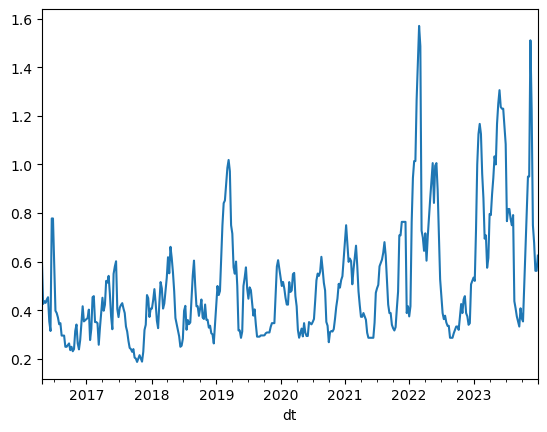

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

original_df = pd.read_csv('../../processed_data/price_weather_weekly_df-2016-2023.csv', parse_dates=['dt'], index_col='dt')
original_df['Alface Crespa - Roça'].plot()
plt.show()

## Análise STL

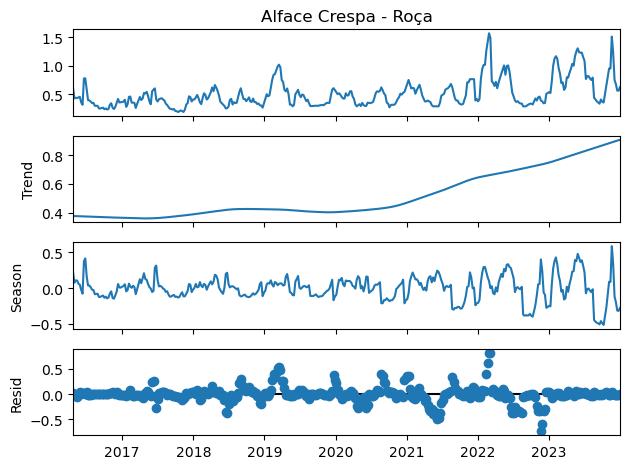

In [18]:
from statsmodels.tsa.stl._stl import STL

stl = STL(original_df['Alface Crespa - Roça'],seasonal=7,robust=True)
res = stl.fit()
fig = res.plot()
plt.show()

In [19]:

from statsmodels.tsa.stattools import adfuller


def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [20]:
from statsmodels.tsa.stattools import kpss


def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)


**Hipóteses do ADF:**
<br>
H0: a série NÃO é estacionária
<br>
Ha: a série é estacionária

se p-valor > 0.05, H0 não pode ser rejeitada
<br>
se p-valor <= 0.05 (?) H0 é rejeitada

In [21]:
adf_test(original_df['Alface Crespa - Roça'])

Results of Dickey-Fuller Test:
Test Statistic                  -5.118568
p-value                          0.000013
#Lags Used                       1.000000
Number of Observations Used    400.000000
Critical Value (1%)             -3.446804
Critical Value (5%)             -2.868793
Critical Value (10%)            -2.570634
dtype: float64


**Hipóteses do KPSS:**
<br>
H0: a série é estacionária
<br>
Ha: a série NÃO é estacionária

se p-valor > 0.05, H0 não pode ser rejeitada
<br>
se p-valor <= 0.05 (?), H0 é rejeitada

In [22]:
kpss_test(original_df['Alface Crespa - Roça'])

Results of KPSS Test:
Test Statistic            1.283
p-value                   0.010
Lags Used                11.000
Critical Value (10%)      0.347
Critical Value (5%)       0.463
Critical Value (2.5%)     0.574
Critical Value (1%)       0.739
dtype: float64


/tmp/ipykernel_18602/2191090818.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


Pelo ADF, a série é estacionária <br>
Pelo KPSS, a série não é estacionária

---

_"Case 4: KPSS indicates non-stationarity and ADF indicates stationarity - The series is difference stationary. Differencing is to be used to make series stationary. The differenced series is checked for stationarity."_


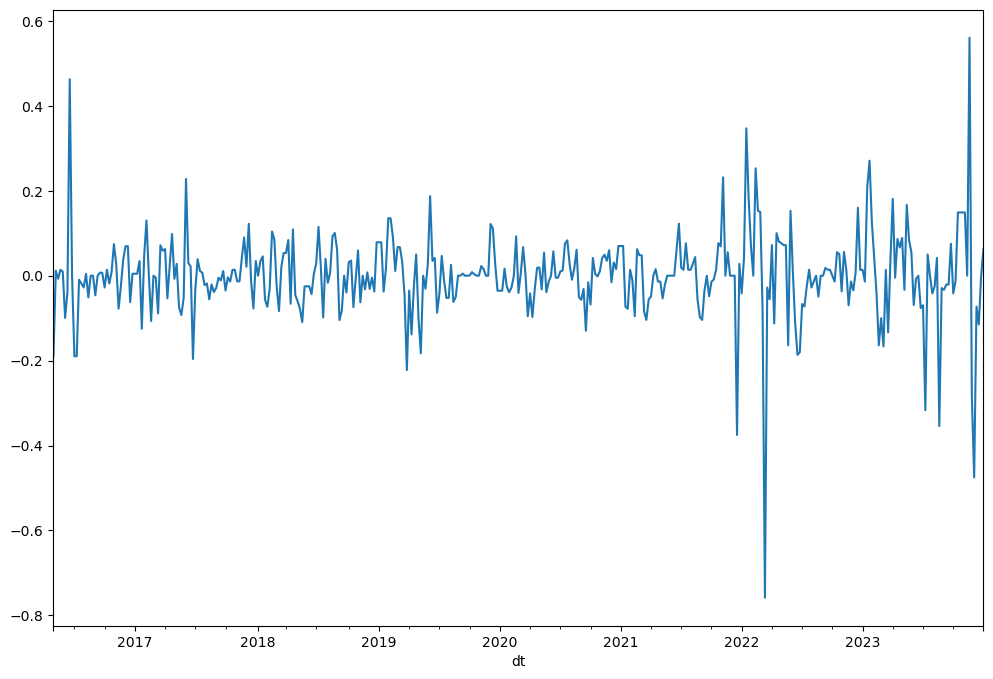

In [23]:
original_df["Alface Crespa - Roça_diff"] = original_df["Alface Crespa - Roça"] - original_df["Alface Crespa - Roça"].shift(
    1
)
original_df["Alface Crespa - Roça_diff"].dropna().plot(figsize=(12, 8))
plt.show()

In [24]:
original_df["Alface Crespa - Roça_diff"]


dt
2016-04-24 00:00:00+00:00         NaN
2016-05-01 00:00:00+00:00   -0.190389
2016-05-08 00:00:00+00:00    0.011667
2016-05-15 00:00:00+00:00   -0.007222
2016-05-22 00:00:00+00:00    0.013889
                               ...   
2023-12-03 00:00:00+00:00   -0.475000
2023-12-10 00:00:00+00:00   -0.072917
2023-12-17 00:00:00+00:00   -0.114583
2023-12-24 00:00:00+00:00    0.000000
2023-12-31 00:00:00+00:00    0.062500
Name: Alface Crespa - Roça_diff, Length: 402, dtype: float64

In [25]:
adf_test(original_df['Alface Crespa - Roça_diff'].dropna())


Results of Dickey-Fuller Test:
Test Statistic                -1.020074e+01
p-value                        5.979733e-18
#Lags Used                     7.000000e+00
Number of Observations Used    3.930000e+02
Critical Value (1%)           -3.447099e+00
Critical Value (5%)           -2.868923e+00
Critical Value (10%)          -2.570703e+00
dtype: float64


In [26]:
kpss_test(original_df['Alface Crespa - Roça_diff'].dropna())


Results of KPSS Test:
Test Statistic           0.015608
p-value                  0.100000
Lags Used                1.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


/tmp/ipykernel_18602/2191090818.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


**Resultado**

Agora, ambos os testes indicam que a série é estacionária após uma diferenciação.
<br>
Isso significa que o parâmetros d e D = 1?

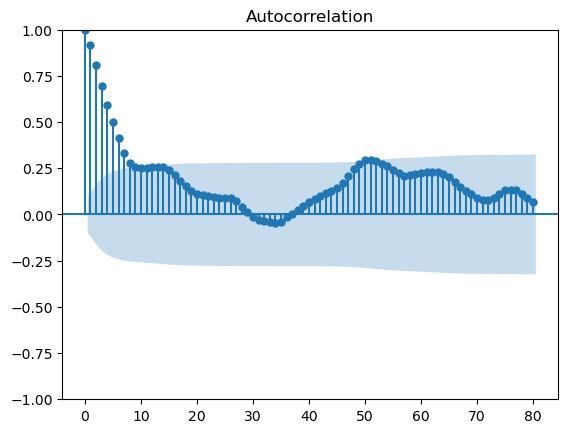

In [27]:
'''
    Load Sunspots Data and plot the autocorrelation of the number of sunspots
    per year.
'''

import matplotlib.pyplot as plt
import pandas as pd

import statsmodels.api as sm

dta = original_df['Alface Crespa - Roça']
#dta.index = pd.Index(sm.tsa.datetools.dates_from_range('1700', '2008'))
sm.graphics.tsa.plot_acf(dta.values.squeeze(), lags=80)
plt.show()

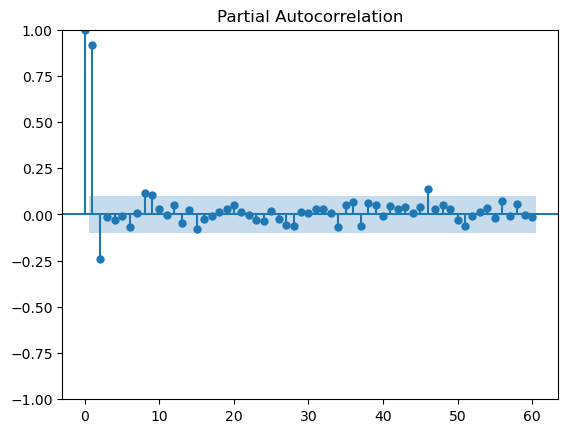

In [28]:
sm.graphics.tsa.plot_pacf(dta.values.squeeze(), lags=60, method="ywm")
plt.show()

Não consegui tirar muita informação daqui, restante dos parâmetros determinar por grid-search.
<br>
modelo: SARIMAX (p,d,q)(P,D,Q,M)
<br>
Com d e D = 1 e M = 56 e Q = 1
<br>
SARIMAX (p, 1, q)(P, 1, Q,, 56)


In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools


def sarimax(ts,exo,all_param):
    results = []
    for param in all_param:
        try:
            mod = SARIMAX(ts,
                          exog = exo,
                          order=param[0],
                          seasonal_order=param[1])
            res = mod.fit()
            results.append((res,res.aic,param))
            print('Tried out SARIMAX{}x{} - AIC:{}'.format(param[0], param[1], round(res.aic,2)))
        except Exception as e:
            print(e)
            continue

    return results
# set parameter range
p,d,q = range(0,2),[1],range(0,2)
P,D,Q,s = range(0,2),[1],range(0,2),[56]
# list of all parameter combos
pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, s))
all_param = list(itertools.product(pdq,seasonal_pdq))
len(all_param)

train = original_df['Alface Crespa - Roça']
exo_train = None
#all_res = sarimax(train,exo_train,all_param)

16

Gridsearch está consumindo muita RAM, por algum motivo. Rodei no Colab. Melhor resultado:<br>
SARIMAX(1, 1, 0)x(0, 1, 1, 56)

/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


Tried out SARIMAX(0, 1, 0)x(0, 1, 0, 56) - AIC:-410.95


/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


Tried out SARIMAX(0, 1, 0)x(0, 1, 1, 56) - AIC:-505.44


/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


...

/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


Tried out SARIMAX(0, 1, 0)x(1, 1, 1, 56) - AIC:-504.68


/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


Tried out SARIMAX(0, 1, 1)x(0, 1, 0, 56) - AIC:-440.52


/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/home/patrick/miniconda3/envs/time-series-analysis2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
